In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

package_path: str = ".."
if package_path not in sys.path:
    sys.path.append(package_path)
    print(f"Added {Path(package_path).resolve()} to sys.path")

working_dir: Path = Path.cwd()
while working_dir.name != "QoraFlow":
    working_dir = working_dir.parent
os.chdir(working_dir)
print(f"Current working directory set to {working_dir.resolve()}")

Added /home/hxpp-admin/Desktop/sogang260903/QoraFlow to sys.path
Current working directory set to /home/hxpp-admin/Desktop/sogang260903/QoraFlow


In [3]:
import matplotlib.pyplot as plt
import numpy as np

from QoraFlow.config import ConfigManager
from QoraFlow.filesystem import get_run_scan_dir
from QoraFlow.integrator.loader import PalXFELLoader

In [4]:
ConfigManager.initialize("config.yaml")

config = ConfigManager.load_config()
load_dir = config.path.load_dir
file = get_run_scan_dir(load_dir, 159, 1, sub_path="p0300.h5")
loader = PalXFELLoader(file)
data = loader.get_data()

pon_images = data["pon"]
pon_qbpm = data["pon_qbpm"]
print(f"{pon_images.shape=}")
print(f"{pon_qbpm.shape=}")

pon_images.shape=(300, 514, 1030)
pon_qbpm.shape=(300,)


Text(0.5, 1.0, 'PON Images mean')

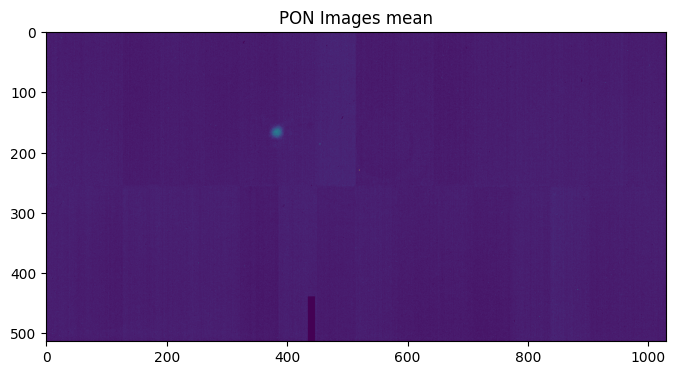

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.imshow(np.log1p(pon_images.mean(axis=0)), cmap="viridis")
ax.set_title("PON Images mean")

Text(0.5, 1.0, 'ROI Images mean')

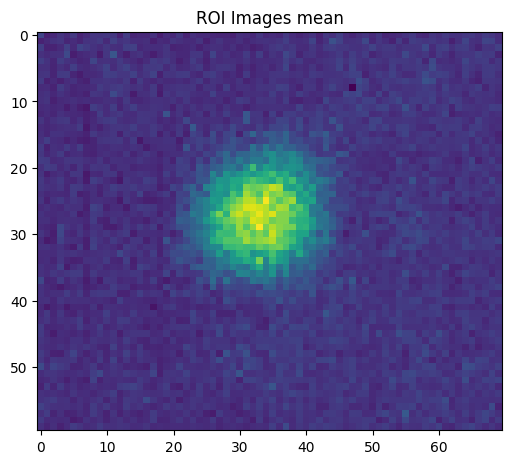

In [16]:
from roi_rectangle import RoiRectangle

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
rect = RoiRectangle(y1=140, y2=200, x1=350, x2=420)
imgs = rect.slice(pon_images)
ax.imshow(np.log1p(imgs.mean(axis=0)), cmap="viridis")
ax.set_title("ROI Images mean")

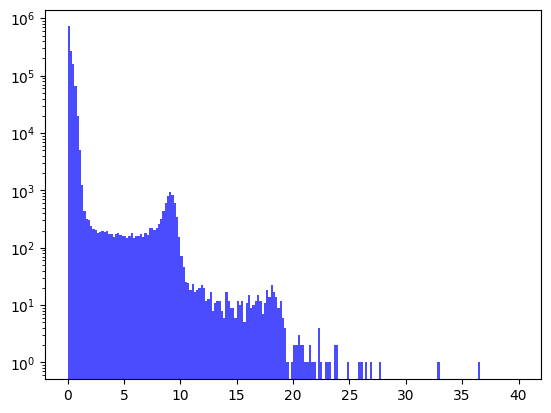

In [17]:
hist, bin_edges = np.histogram(imgs.ravel(), bins=200, range=(0, 40), density=None)

plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), color='blue', alpha=0.7, align='edge')
plt.yscale('log')

/tmp/ipykernel_2159363/508343526.py:5: RuntimeWarning: divide by zero encountered in log
  soft_hist = gaussian_filter(np.log(hist), sigma=2)
/home/hxpp-admin/Desktop/sogang260903/QoraFlow/.venv/lib/python3.12/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


Indices:  [ 0 45 89]


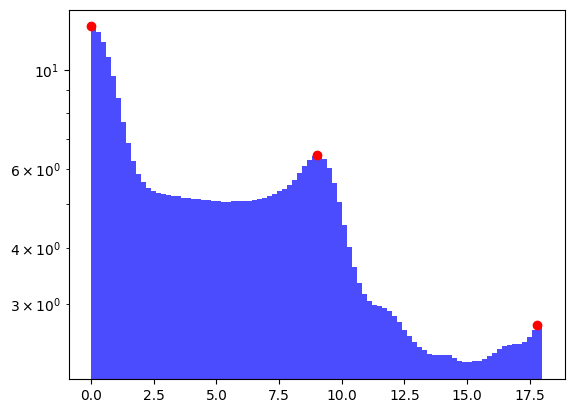

In [20]:
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks

# Apply Gaussian filter to the histogram
soft_hist = gaussian_filter(np.log(hist), sigma=2)

# Find peaks in the filtered histogram
indices = find_peaks(soft_hist, distance=10, prominence=0.1, rel_height=0.5)[0]
indices = np.concatenate([[0], indices], axis=0)
print("Indices: ", indices)

plt.bar(bin_edges[:-1], soft_hist, width=np.diff(bin_edges), color='blue', alpha=0.7, align='edge')
plt.scatter(bin_edges[indices], soft_hist[indices], color='red', label='Peaks')
plt.yscale('log')

In [21]:
print("LSB is", np.diff(bin_edges[indices]).mean())

LSB is 8.9
